In [1]:
import pandas as pd
import numpy as np

In [12]:
basics = pd.read_csv("Data/Merege_data_with_Sasha/ready_to_train.csv")

In [13]:
basics.columns
basics.shape

(5010, 11)

In [14]:
basics.head(1)

,tconst,primaryTitle,startYear,averageRating,numVotes,genre_score,movie_writer_quality,movie_actor_score,budget,director_quality,top_3_actor_scores
0,tt10103028,Blindfire,2020,4.9,807,5.934379,4.9,6.312799,2.541177e+07,4.9,930.333333


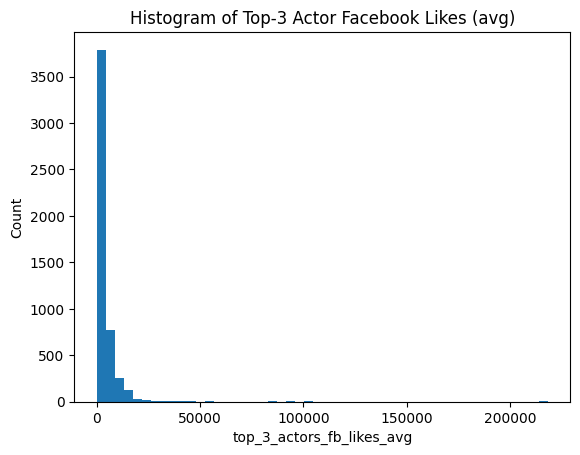

In [17]:
import matplotlib.pyplot as plt
df = basics.copy()
plt.hist(df['top_3_actor_scores'], bins=50)
plt.title("Histogram of Top‑3 Actor Facebook Likes (avg)")
plt.xlabel("top_3_actors_fb_likes_avg")
plt.ylabel("Count")
plt.show()


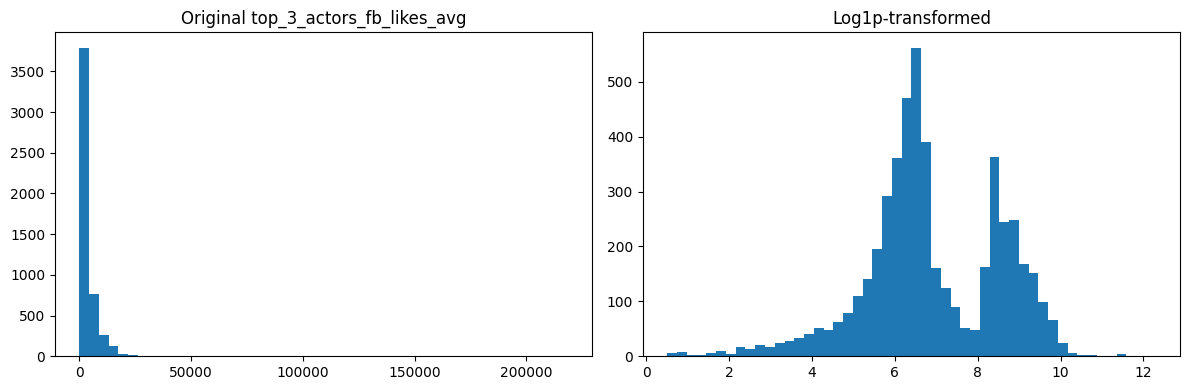

Pearson(original) = 0.012
Pearson(log1p)    = -0.020


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Log1p‑transform (zeros become log1p(0)=0; large values get compressed)
df['log_top3_fb'] = np.log1p(df['top_3_actor_scores'])

# 2) Plot original vs. log‑transformed distributions
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df['top_3_actor_scores'].dropna(), bins=50)
plt.title("Original top_3_actors_fb_likes_avg")

plt.subplot(1,2,2)
plt.hist(df['log_top3_fb'].dropna(), bins=50)
plt.title("Log1p‑transformed")

plt.tight_layout()
plt.show()

# 3) Compute & print Pearson on both
orig_corr   = df['top_3_actor_scores'].corr(df['averageRating'])
log_corr    = df['log_top3_fb']       .corr(df['averageRating'])

print(f"Pearson(original) = {orig_corr:.3f}")
print(f"Pearson(log1p)    = {log_corr:.3f}")


In [21]:
df.to_csv(
    'Data/Merege_data_with_Sasha/movies_features_with_social_Metadata_with_log.csv',
    index=False
)

In [23]:
test = pd.read_csv('Data/Merege_data_with_Sasha/movies_features_with_social_Metadata_with_log.csv')
test.head(5)

,tconst,primaryTitle,startYear,averageRating,numVotes,genre_score,movie_writer_quality,movie_actor_score,budget,director_quality,top_3_actor_scores,log_top3_fb
0,tt10103028,Blindfire,2020,4.9,807,5.934379,4.900000,6.312799,2.541177e+07,4.900000,930.333333,6.836617
1,tt29173358,BJJ: Woman on Top,2023,4.3,143,6.222951,4.775000,5.584329,2.244917e+07,4.950000,15333.333333,9.637850
2,tt10276160,Weekend,2020,4.8,311,5.914762,4.800000,6.594587,2.553168e+07,4.800000,3851.333333,8.256434
3,tt20511498,Plancha,2022,5.4,702,5.885894,5.350000,6.509762,2.828938e+07,5.350000,24333.333333,10.099644
4,tt13575922,Cheeni,2020,6.4,786,6.222951,6.562024,7.932981,2.244917e+07,6.733333,71.500000,4.283587
